In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [9]:
d1=pd.read_csv("Customer_Master_Data.csv")
d2=pd.read_csv("Customer_Transactions.csv")

In [10]:
invalid_ids = d2[~d2["CustomerID"].isin(d1["CustomerID"])]
print("Invalid transaction CustomerIDs:", len(invalid_ids))

Invalid transaction CustomerIDs: 0


In [11]:
d1

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04
...,...,...,...,...,...,...,...,...,...
995,CUST10995,Mehul Chada,hridaanagate@hotmail.com,Male,70,Hyderabad,Divorced,2,2020-07-29
996,CUST10996,Arhaan Tara,qwali@mand-sood.com,Male,35,Delhi,Single,1,2022-07-24
997,CUST10997,Mahika Uppal,vdalal@yahoo.com,Female,70,Ahmedabad,Married,3,2023-01-27
998,CUST10998,Bhamini Aggarwal,kartik15@bajaj-singhal.com,Male,37,Jaipur,Single,0,2022-07-22


In [12]:
df=d1.merge(d2)

In [13]:
df

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,10/3/22,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,5/31/24,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,5/31/24,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,1/31/23,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,6/12/22,912.08
...,...,...,...,...,...,...,...,...,...,...,...
23045,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,6/25/25,1883.60
23046,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,2/12/25,243.54
23047,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,10/9/24,1081.81
23048,CUST10999,Alia Sekhon,urvichadha@hotmail.com,Male,67,Hyderabad,Widowed,1,2021-09-07,3/15/23,1619.39


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23050 entries, 0 to 23049
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   Name               23050 non-null  object 
 2   Email              23050 non-null  object 
 3   Gender             23050 non-null  object 
 4   Age                23050 non-null  int64  
 5   City               23050 non-null  object 
 6   MaritalStatus      23050 non-null  object 
 7   NumChildren        23050 non-null  int64  
 8   JoinDate           23050 non-null  object 
 9   TransactionDate    23050 non-null  object 
 10  TransactionAmount  23050 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


In [15]:
df["JoinDate"]=pd.to_datetime(df["JoinDate"])

In [16]:
df["TransactionDate"]=pd.to_datetime(df["TransactionDate"])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23050 entries, 0 to 23049
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  object        
 1   Name               23050 non-null  object        
 2   Email              23050 non-null  object        
 3   Gender             23050 non-null  object        
 4   Age                23050 non-null  int64         
 5   City               23050 non-null  object        
 6   MaritalStatus      23050 non-null  object        
 7   NumChildren        23050 non-null  int64         
 8   JoinDate           23050 non-null  datetime64[ns]
 9   TransactionDate    23050 non-null  datetime64[ns]
 10  TransactionAmount  23050 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 2.1+ MB


In [18]:
df.nunique()

CustomerID            1000
Name                   993
Email                 1000
Gender                   3
Age                     58
City                    10
MaritalStatus            4
NumChildren              5
JoinDate               727
TransactionDate       1713
TransactionAmount    21810
dtype: int64

In [19]:
df.duplicated().sum()

0

In [20]:
df.isnull().sum()

CustomerID           0
Name                 0
Email                0
Gender               0
Age                  0
City                 0
MaritalStatus        0
NumChildren          0
JoinDate             0
TransactionDate      0
TransactionAmount    0
dtype: int64

In [21]:
df["Gender"].value_counts()

Female           7738
Male             7710
Not Disclosed    7602
Name: Gender, dtype: int64

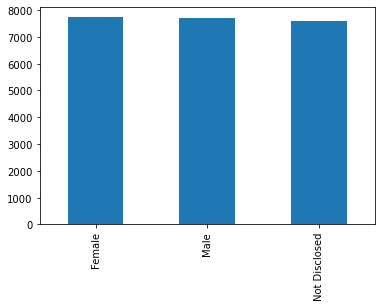

In [22]:
df["Gender"].value_counts().plot.bar()
plt.show()

In [23]:
df["City"].value_counts()

Lucknow      2574
Jaipur       2523
Hyderabad    2371
Bangalore    2339
Delhi        2309
Mumbai       2293
Ahmedabad    2273
Chennai      2175
Pune         2139
Kolkata      2054
Name: City, dtype: int64

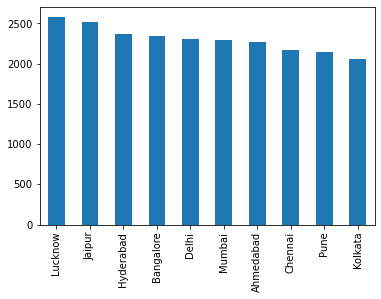

In [24]:
df["City"].value_counts().plot.bar()
plt.show()

In [25]:
df["NumChildren"].value_counts()

0    7270
1    6428
2    5366
3    2687
4    1299
Name: NumChildren, dtype: int64

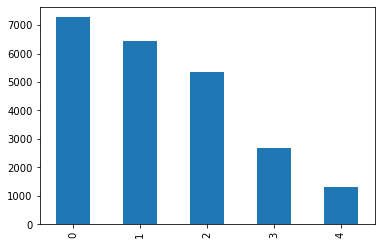

In [26]:
df["NumChildren"].value_counts().plot.bar()
plt.show()

In [27]:
df["TransactionDate"].max()

Timestamp('2025-07-29 00:00:00')

In [28]:
df["TransactionDate"].min()

Timestamp('2020-08-22 00:00:00')

In [29]:
ref_date=df["TransactionDate"].max()+pd.Timedelta(days=1)

In [30]:
rfm=df.groupby("CustomerID").agg({"TransactionAmount":"sum",
                              "CustomerID":"count"})

In [31]:
rfm.columns=["Monetary","Frequency"]

In [32]:
rfm

,Monetary,Frequency
CustomerID,,
CUST10000,21265.49,23
CUST10001,28654.31,30
CUST10002,23884.03,24
CUST10003,24206.03,25
CUST10004,25565.30,19
...,...,...
CUST10995,24325.19,21
CUST10996,21809.11,21
CUST10997,21120.48,20


In [33]:
rec=df.groupby("CustomerID").agg({"TransactionDate":"max"})

In [34]:
rfm["Recency"]=ref_date-rec

In [35]:
rfm["Recency"]

CustomerID
CUST10000    13 days
CUST10001    35 days
CUST10002    18 days
CUST10003    81 days
CUST10004     8 days
              ...   
CUST10995   402 days
CUST10996    15 days
CUST10997    32 days
CUST10998   126 days
CUST10999     5 days
Name: Recency, Length: 1000, dtype: timedelta64[ns]

In [36]:
rfm["Recency"] = rfm["Recency"].dt.days

In [37]:
rfm

,Monetary,Frequency,Recency
CustomerID,,,
CUST10000,21265.49,23,13
CUST10001,28654.31,30,35
CUST10002,23884.03,24,18
CUST10003,24206.03,25,81
CUST10004,25565.30,19,8
...,...,...,...
CUST10995,24325.19,21,402
CUST10996,21809.11,21,15
CUST10997,21120.48,20,32


In [38]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, [5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"], 5, [1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, [1,2,3,4,5])


rfm

,Monetary,Frequency,Recency,R_score,F_score,M_score
CustomerID,,,,,,
CUST10000,21265.49,23,13,4,3,2
CUST10001,28654.31,30,35,3,5,5
CUST10002,23884.03,24,18,4,3,3
CUST10003,24206.03,25,81,1,4,3
CUST10004,25565.30,19,8,5,1,4
...,...,...,...,...,...,...
CUST10995,24325.19,21,402,1,2,3
CUST10996,21809.11,21,15,4,2,3
CUST10997,21120.48,20,32,3,2,2


In [39]:
rfm["final_score"]=rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str) 

In [40]:
rfm

,Monetary,Frequency,Recency,R_score,F_score,M_score,final_score
CustomerID,,,,,,,
CUST10000,21265.49,23,13,4,3,2,432
CUST10001,28654.31,30,35,3,5,5,355
CUST10002,23884.03,24,18,4,3,3,433
CUST10003,24206.03,25,81,1,4,3,143
CUST10004,25565.30,19,8,5,1,4,514
...,...,...,...,...,...,...,...
CUST10995,24325.19,21,402,1,2,3,123
CUST10996,21809.11,21,15,4,2,3,423
CUST10997,21120.48,20,32,3,2,2,322


In [41]:
def segment_customer(row):

    if row['R_score'] == 5 and row['F_score'] == 5 and row['M_score'] == 5:
        return 'Champions'
    
    elif row['F_score'] in [4, 5] and row['R_score'] in [2, 3, 4, 5]:
        return 'Loyal Customers'
    
    elif row['R_score'] in [4, 5] and row['F_score'] in [2, 3]:
        return 'Potential Loyalist'
    
    elif row['R_score'] in [1, 2] and row['F_score'] in [3, 4, 5]:
        return 'At Risk'
    
    elif row['R_score'] == 1 and row['F_score'] in [1, 2] and row['M_score'] in [1, 2]:
        return 'Lost'
    
    elif row['M_score'] in [4, 5] and row['F_score'] in [2, 3] and row['R_score'] in [3, 4]:
        return 'Big Spenders'
    
    else:
        return 'Others'

In [42]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [43]:
rfm.head(20)

,Monetary,Frequency,Recency,R_score,F_score,M_score,final_score,Segment
CustomerID,,,,,,,,
CUST10000,21265.49,23,13,4,3,2,432,Potential Loyalist
CUST10001,28654.31,30,35,3,5,5,355,Loyal Customers
CUST10002,23884.03,24,18,4,3,3,433,Potential Loyalist
CUST10003,24206.03,25,81,1,4,3,143,At Risk
CUST10004,25565.30,19,8,5,1,4,514,Others
CUST10005,29459.82,29,24,4,5,5,455,Loyal Customers
CUST10006,27922.36,28,11,5,5,5,555,Champions
CUST10007,14957.06,15,86,1,1,1,111,Lost
CUST10008,19479.25,19,3,5,1,2,512,Others


In [44]:
rfm["Segment"].value_counts()

Others                289
Loyal Customers       283
Potential Loyalist    167
At Risk               130
Lost                   76
Champions              35
Big Spenders           20
Name: Segment, dtype: int64

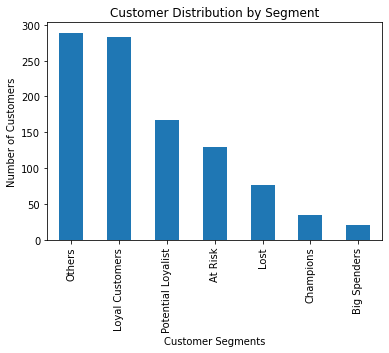

In [45]:
rfm["Segment"].value_counts().plot.bar()
plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segments")
plt.ylabel("Number of Customers")
plt.show()

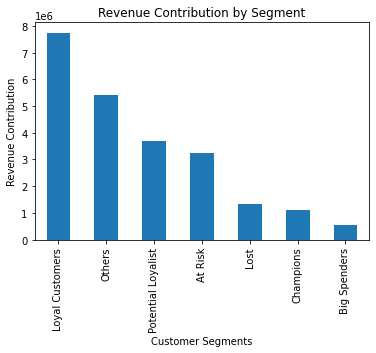

In [46]:
rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False).plot.bar()
plt.title("Revenue Contribution by Segment")
plt.xlabel("Customer Segments")
plt.ylabel("Revenue Contribution")
plt.show()

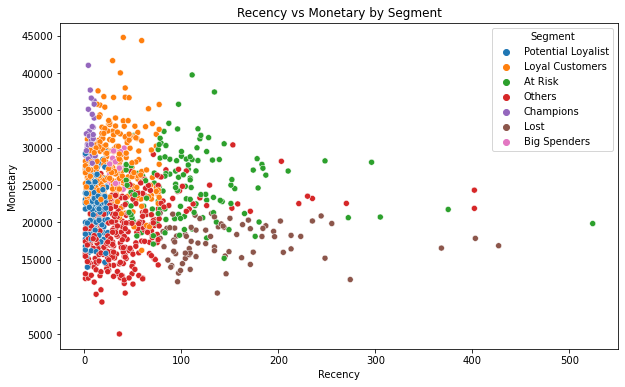

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment' 
)

plt.title("Recency vs Monetary by Segment")
plt.show()

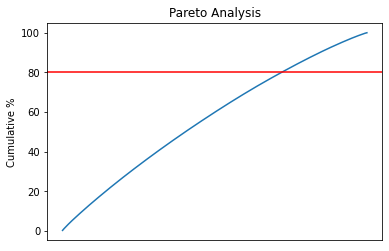

In [53]:
rfm_sorted = rfm.sort_values(by='Monetary', ascending=False)

rfm_sorted['cum_sum'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['cum_percent'] = 100 * rfm_sorted['cum_sum'] / rfm_sorted['Monetary'].sum()

plt.plot(rfm_sorted['cum_percent'])
plt.axhline(80, color='red')

plt.xticks([])

plt.title("Pareto Analysis")
plt.ylabel("Cumulative %")

plt.show()

In [ ]:
"""We can clearly see that a small percentage of top customers contribute to around 80% of the total revenue."""

In [49]:
insights = """
INSIGHTS:

1. Most customers belong to 'Others' and 'Loyal Customers'.
2. Champions generate high revenue despite smaller count.
3. At Risk customers need re-engagement strategies.
4. Top customers contribute majority of revenue (Pareto principle).
5. Focus marketing on retention and loyalty programs.
"""
print(insights)


INSIGHTS:

1. Most customers belong to 'Others' and 'Loyal Customers'.
2. Champions generate high revenue despite smaller count.
3. At Risk customers need re-engagement strategies.
4. Top customers contribute majority of revenue (Pareto principle).
5. Focus marketing on retention and loyalty programs.

